# Évaluation Finale et Optimisation du Modèle

Ce notebook présente l'évaluation finale du modèle sur le jeu de test. Il se concentre sur l'analyse des probabilités prédites et l'optimisation du seuil de décision en tenant compte des coûts asymétriques du domaine de la cybersécurité.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, f1_score
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")


## 1. Chargement des Données et du Modèle Final


In [19]:
try:
    test_df = pd.read_csv('../data/processed/test.csv')
    X_test = test_df.drop(columns=['is_phishing'])
    y_test = test_df['is_phishing']
    
    # Reconstitution des colonnes attendues par le pipeline
    age_cols = [c for c in X_test.columns if c.startswith('domain_age_category_')]
    if age_cols:
        X_test['domain_age_category'] = X_test[age_cols].idxmax(axis=1).str.replace('domain_age_category_', '')
        X_test = X_test.drop(columns=age_cols)
        
    if 'country' not in X_test.columns:
        X_test['country'] = 'UNKNOWN'
    
    model = joblib.load('../models/final_model.joblib')
    print("Modèle et données de test chargés avec succès.")
    
except FileNotFoundError:
    print("Erreur : Veuillez vérifier la présence des fichiers dans data/processed/ et models/.")


Modèle et données de test chargés avec succès.


## 2. Analyse de la Distribution des Probabilités Prédites

Cette section visualise la capacité du modèle à séparer les URL légitimes des URL de phishing avant l'application d'un seuil strict.


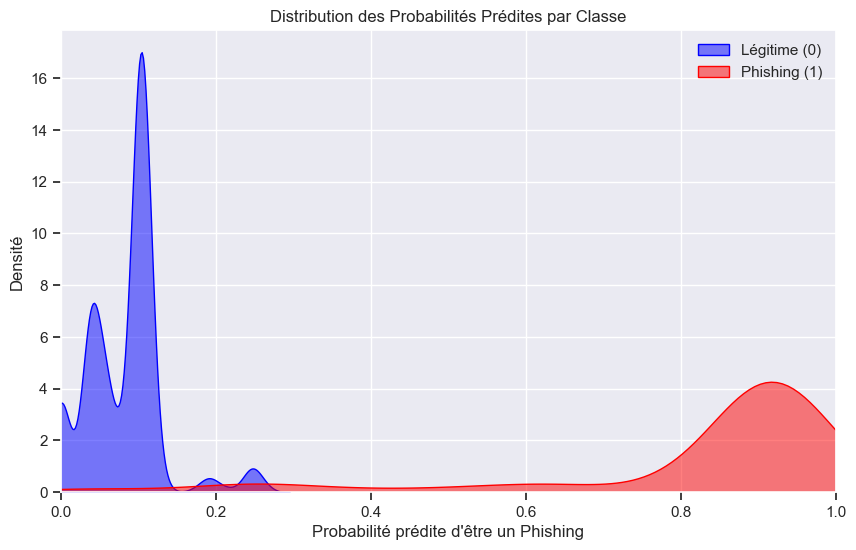

In [20]:
y_proba = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
sns.kdeplot(y_proba[y_test == 0], label='Légitime (0)', fill=True, color='blue', alpha=0.5)
sns.kdeplot(y_proba[y_test == 1], label='Phishing (1)', fill=True, color='red', alpha=0.5)
plt.title('Distribution des Probabilités Prédites par Classe')
plt.xlabel('Probabilité prédite d\'être un Phishing')
plt.ylabel('Densité')
plt.legend()
plt.xlim(0, 1)
plt.show()


## 3. Optimisation du Seuil de Décision selon les Coûts Métiers

### 3.1 Calcul des métriques et des coûts par seuil

L'évaluation utilise une matrice de coût asymétrique pour refléter l'impact réel : un Faux Négatif (fraude non détectée) coûte beaucoup plus cher qu'un Faux Positif (friction utilisateur).


In [21]:
COUT_FN = 1000 
COUT_FP = 50   

seuils = np.arange(0.1, 0.91, 0.01)
precisions, recalls, couts = [], [], []

for seuil in seuils:
    y_pred_seuil = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_seuil).ravel()
    
    precisions.append(precision_score(y_test, y_pred_seuil, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_seuil, zero_division=0))
    couts.append((fn * COUT_FN) + (fp * COUT_FP))

index_optimal = np.argmin(couts)
seuil_optimal = seuils[index_optimal]
cout_min = couts[index_optimal]

print(f"Seuil optimal identifié : {seuil_optimal:.2f}")
print(f"Coût minimum associé : {cout_min}")


Seuil optimal identifié : 0.19
Coût minimum associé : 10100


### 3.2 Évolution des Performances en fonction du Seuil


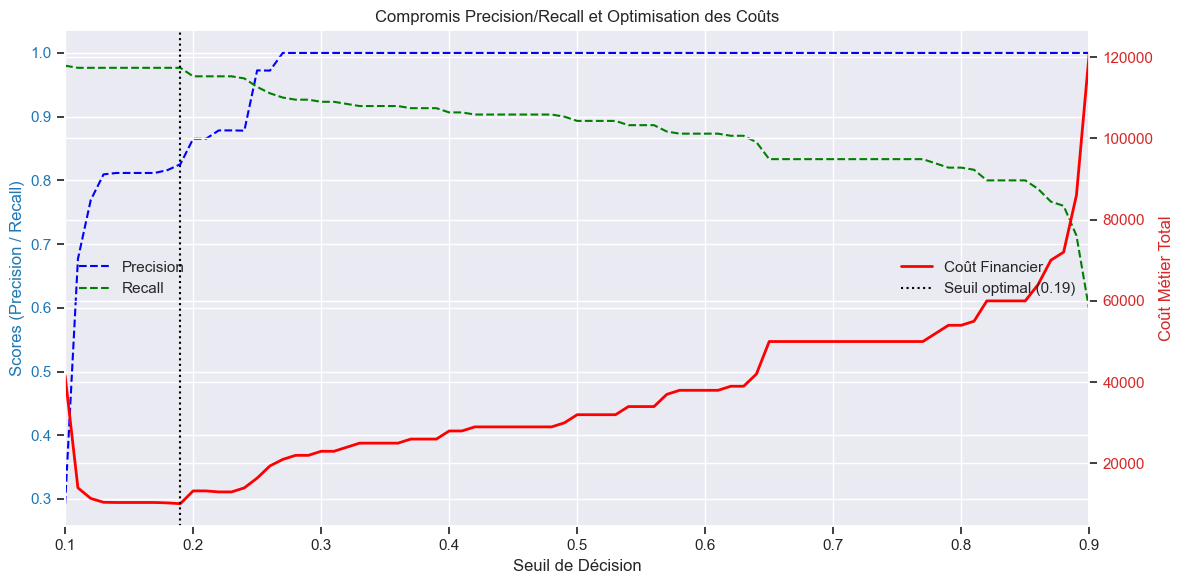

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Seuil de Décision')
ax1.set_ylabel('Scores (Precision / Recall)', color=color)
ax1.plot(seuils, precisions, label='Precision', color='blue', linestyle='--')
ax1.plot(seuils, recalls, label='Recall', color='green', linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='center left')
ax1.set_xlim(0.1, 0.9)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coût Métier Total', color=color)
ax2.plot(seuils, couts, label='Coût Financier', color='red', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axvline(x=seuil_optimal, color='black', linestyle=':', label=f'Seuil optimal ({seuil_optimal:.2f})')
ax2.legend(loc='center right')

plt.title('Compromis Precision/Recall et Optimisation des Coûts')
fig.tight_layout()
plt.show()


### 3.3 Comparaison des Matrices de Confusion et Validation des Objectifs


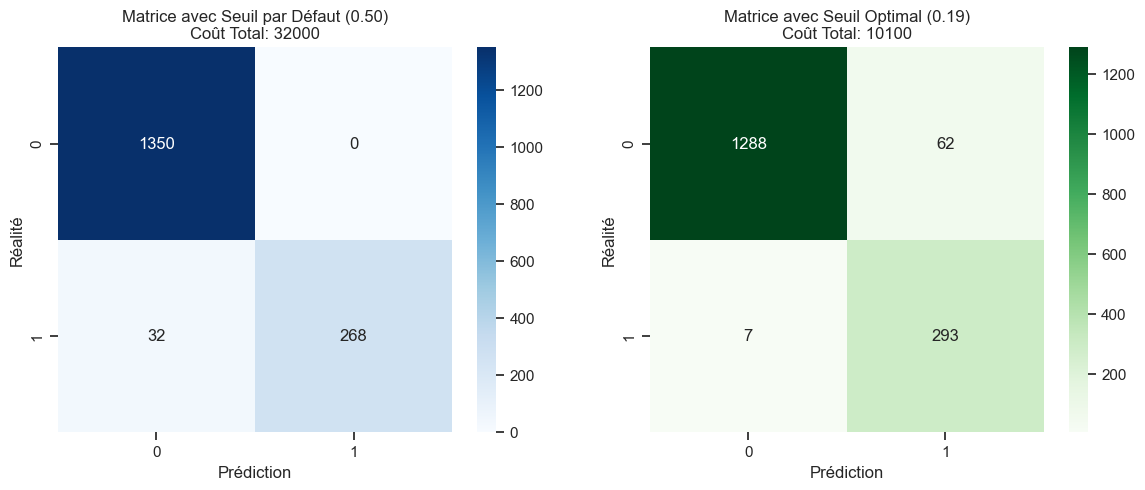

=== Performances Finales avec le Seuil Optimal ===
Recall (Cible >= 0.90) : 0.977
Precision (Cible >= 0.65) : 0.825
F1-Score (Cible >= 0.80) : 0.895


In [23]:
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_optimal = (y_proba >= seuil_optimal).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
cout_default = (cm_default[1,0]*COUT_FN) + (cm_default[0,1]*COUT_FP)
axes[0].set_title(f"Matrice avec Seuil par Défaut (0.50)\nCoût Total: {cout_default}")
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Réalité")

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Matrice avec Seuil Optimal ({seuil_optimal:.2f})\nCoût Total: {cout_min}")
axes[1].set_xlabel("Prédiction")
axes[1].set_ylabel("Réalité")

plt.show()

print("=== Performances Finales avec le Seuil Optimal ===")
print(f"Recall (Cible >= 0.90) : {recall_score(y_test, y_pred_optimal):.3f}")
print(f"Precision (Cible >= 0.65) : {precision_score(y_test, y_pred_optimal):.3f}")
print(f"F1-Score (Cible >= 0.80) : {f1_score(y_test, y_pred_optimal):.3f}")
